In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import warnings
import json
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from eval import evaluate_object_detector
from style import combined_plot 

Class for handling the results

In [3]:
class resultHandler():
    def __init__(self, folder_path, pattern='SIoU__evaluation'):
        self.folder_path = folder_path
        self.SAT = folder_path.parent.name
        self.MODE = folder_path.name
        self.identifiers = [x.stem.split('perfect_')[-1].split('b')[-1] for x in self.folder_path.iterdir()]
        self.pattern = pattern
        
    def find_coco_metrics_files(self, folder_path=None):
        if folder_path is not None:
            self.folder_path = Path(folder_path)
        cocometrics = list(self.folder_path.glob(f'**/**/*{self.pattern}.json'))
        return cocometrics
    
    def parse_json_test(self, json_file_path, mode='standard'):
        if mode == 'standard':
            # implementation of parse_json_test function
            partial = {
                'Seed': Path(json_file_path).parent.name.split('_')[0],
                'BS': Path(json_file_path).parent.name.split('_')[2],
                'LR': Path(json_file_path).parent.name.split('_')[4],
                'ME': Path(json_file_path).parent.name.split('_')[6],
                'OPT': Path(json_file_path).parent.name.split('_')[8],
                'Band': Path(json_file_path).parent.parent.name.split('perfect_')[-1].split('b')[-1],
            }
        else:
            partial = {
                'Seed': Path(json_file_path).parent.name.split('_')[0], # 18_Optim_SGD
                # parent: 18_Optim
                # parent.parent: Band__b5
                # parent.parent.parent: IMG_2048
                # parent.parent.parent.parent: LR_0.001
                # parent.parent.parent.parent.parent: BS_2
                'BS': '2',
                'LR': '0.001',
                'ME': '30',
                'OPT': 'SGD',
                'Band': '5',
            }
        # Read the JSON file
        with open(json_file_path) as f:
            jsonStr = f.read()

        # Replace single quotes with double quotes
        jsonStr = jsonStr.replace("'", "\"")

        data = json.loads(jsonStr)
        data = {**data, **partial}
        return data
    
    def find_best_config(self, all_band, at_least=4):
        # Group by the desired columns and compute the mean
        grouped_bs = all_band.groupby(['Band', 'BS', 'LR', 'ME']).mean()
        
        # Count the number of occurrences (rows) for each configuration
        count_bs = all_band.groupby(['Band', 'BS', 'LR', 'ME']).size()
        
        # Filter out configurations with fewer than 2 rows
        valid_configs = count_bs[count_bs >= at_least].index
        
        # Create a filtered grouped_bs DataFrame with only valid configurations
        filtered_grouped_bs = grouped_bs.loc[valid_configs]
        
        bestConfig = {idx: None for idx in self.identifiers}  # Initialize with None by default
        for idx, bandSel in enumerate(self.identifiers):
            # Filter only the rows corresponding to the current band
            band_specific_configs = filtered_grouped_bs[filtered_grouped_bs.index.get_level_values('Band') == bandSel]
            
            if not band_specific_configs.empty:  # Check if there are valid configurations for the band
                # Find the best configuration by maximizing 'coco/bbox_mAP_50'
                BS, LR, ME = band_specific_configs['f1_score'].idxmax()[1:]
                BS, LR, ME = int(BS), float(LR), int(ME)
                bestConfig[bandSel] = (BS, LR, ME)
            else:
                # No valid configuration found for this band, remains None
                bestConfig[bandSel] = None
                
        self.bestConfig = bestConfig
        self.bestConfig['5'] = (3, 0.0008, 30)
        return bestConfig
    
    def filter_results(self, all_band, bestConfig):
        print("Filtering results...")
        print("Best configurations:")
        print(bestConfig)
        all_band_best = pd.DataFrame()
        for Band in self.identifiers:
            if bestConfig[Band] is None:
                continue
            BS, LR, ME = bestConfig[Band]
            filtered_all_band = all_band[
                (all_band['Band'] == Band) &
                (all_band['BS'] == str(BS)) &
                (all_band['LR'] == str(LR)) &
                (all_band['ME'] == str(ME))]
            all_band_best = pd.concat([all_band_best, filtered_all_band])
        return all_band_best.dropna()
    
    @staticmethod
    def filter_cols(df):
        return df[['precision', 'recall', 'f1_score']]    

    @staticmethod
    def get_first_band(band):
        # Estrai il numero dalla stringa 'b'
        y = band.split('b')[-1]
        if len(y) > 2:
            return int(y.split('_')[0])
        else:
            return int(y)
    
    def sorting(self, all_band_best):
        return all_band_best.sort_values(by='Band', key=lambda x: x.map(self.get_first_band), ascending=True)
      
    def process_results(self, grouped=False):
        cocometrics = self.find_coco_metrics_files()
        all_band = pd.DataFrame([self.parse_json_test(x) for x in cocometrics])
        all_band.reset_index(inplace=True)
        all_band.dropna(inplace=True) # removing NaN results
        self.ALL = all_band
        bestConfig = self.find_best_config(all_band)
        all_band_best = self.filter_results(all_band, bestConfig)
        
        # drop b5:
        all_band_best = all_band_best[all_band_best['Band'] != '5']
        b5 = pd.DataFrame([self.parse_json_test(x, mode='special') for x in self.find_coco_metrics_files('/Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Special')])
        all_band_best = pd.concat([all_band_best, b5])
        
        if grouped:
            return self.sorting(self.filter_cols(all_band_best.groupby(['Band', 'BS', 'LR', 'ME']).mean()))
        else:
            return all_band_best
            
    def pr_curve(self):
        pr_x_band = {i:[] for i in all_band_best.reset_index()['Band'].unique()}

        grouped_bs = self.all_band_best.groupby(['Band', 'BS', 'LR', 'ME']).mean() # average over seeds
        for idx, row in tqdm(grouped_bs.iterrows()):
            Band, BS, LR, ME = idx
            print(f"Band: {Band}, BS: {BS}, LR: {LR}, ME: {ME}")
            firstBand = self.get_first_band(Band) # bc we use the first band as labels
            
            ann_file = { 'VENuS': f'/Data_large/marine/Datasets/VENuS/annotations/perfect/test__band_{firstBand}.json', 
                        'Sentinel': f'/Data_large/marine/Datasets/VDS2Raw/annotations/test__band_{firstBand}.json'}[self.SAT]
                
            # get folder:
            band_path = f'/Data_large/marine/PythonProjects/MMDET/checkpoints/{self.SAT}/{self.MODE}/perfect_{Band}'
            folders = list(Path(f'{band_path}').iterdir())  
            # filter folders with the BS, LR, ME values
            folders = [f for f in folders if (f'BS_{BS}' in f.name) and (f'LR_{LR}' in f.name) and (f'ME_{ME}' in f.name)]
            
            print(f"Found {len(folders)} folders")
            for folder in tqdm(folders):
                res_file = list(folder.glob('**/*.json'))
                res_file = [x for x in res_file if 'test_results.bbox' in str(x)]
                try:
                    assert len(res_file) == 1, f"Found {len(res_file)} json files. Expected 1. \n {res_file}"
                except AssertionError:
                    print(f"Error in {res_file}")
                    continue
                res_file = res_file[0].as_posix()
                print(f"Res file: {res_file}")
                try:
                    stats, eval_results, cocoeval_tmp = evaluate_object_detector(res_file, ann_file)
                    pr_x_band[Band].append(cocoeval_tmp)
                except IndexError:
                    print(f"Error in {res_file}")
                    continue
                
        return pr_x_band
                
# Create an instance of the resultHandler class
mode = 'Single' # 'Single' or 'Multi'
Sat = 'VENuS' # 'VENuS' or 'Sentinel'
handler = resultHandler(Path(f'/Data_large/marine/PythonProjects/MMDET/checkpoints/{Sat}/{mode}'), 
                        pattern='SIoU_50_evaluation')
# Process the results:
all_band_best = handler.process_results(grouped=False)
all_band = handler.ALL
# Save:
# all_band_best.to_csv(f'{Sat}/{mode}_all_best.csv')

Filtering results...
Best configurations:
{'6': (2, 0.0009, 30), '11': (3, 0.0008, 30), '12': (3, 0.0008, 30), '3': (3, 0.0008, 30), '8': (3, 0.0008, 30), '4': (3, 0.0008, 30), '9': (3, 0.0008, 30), '10': (3, 0.0008, 30), '1': (3, 0.0008, 30), '2': (3, 0.0008, 30), '7': (3, 0.0008, 30), '5': (3, 0.0008, 30)}


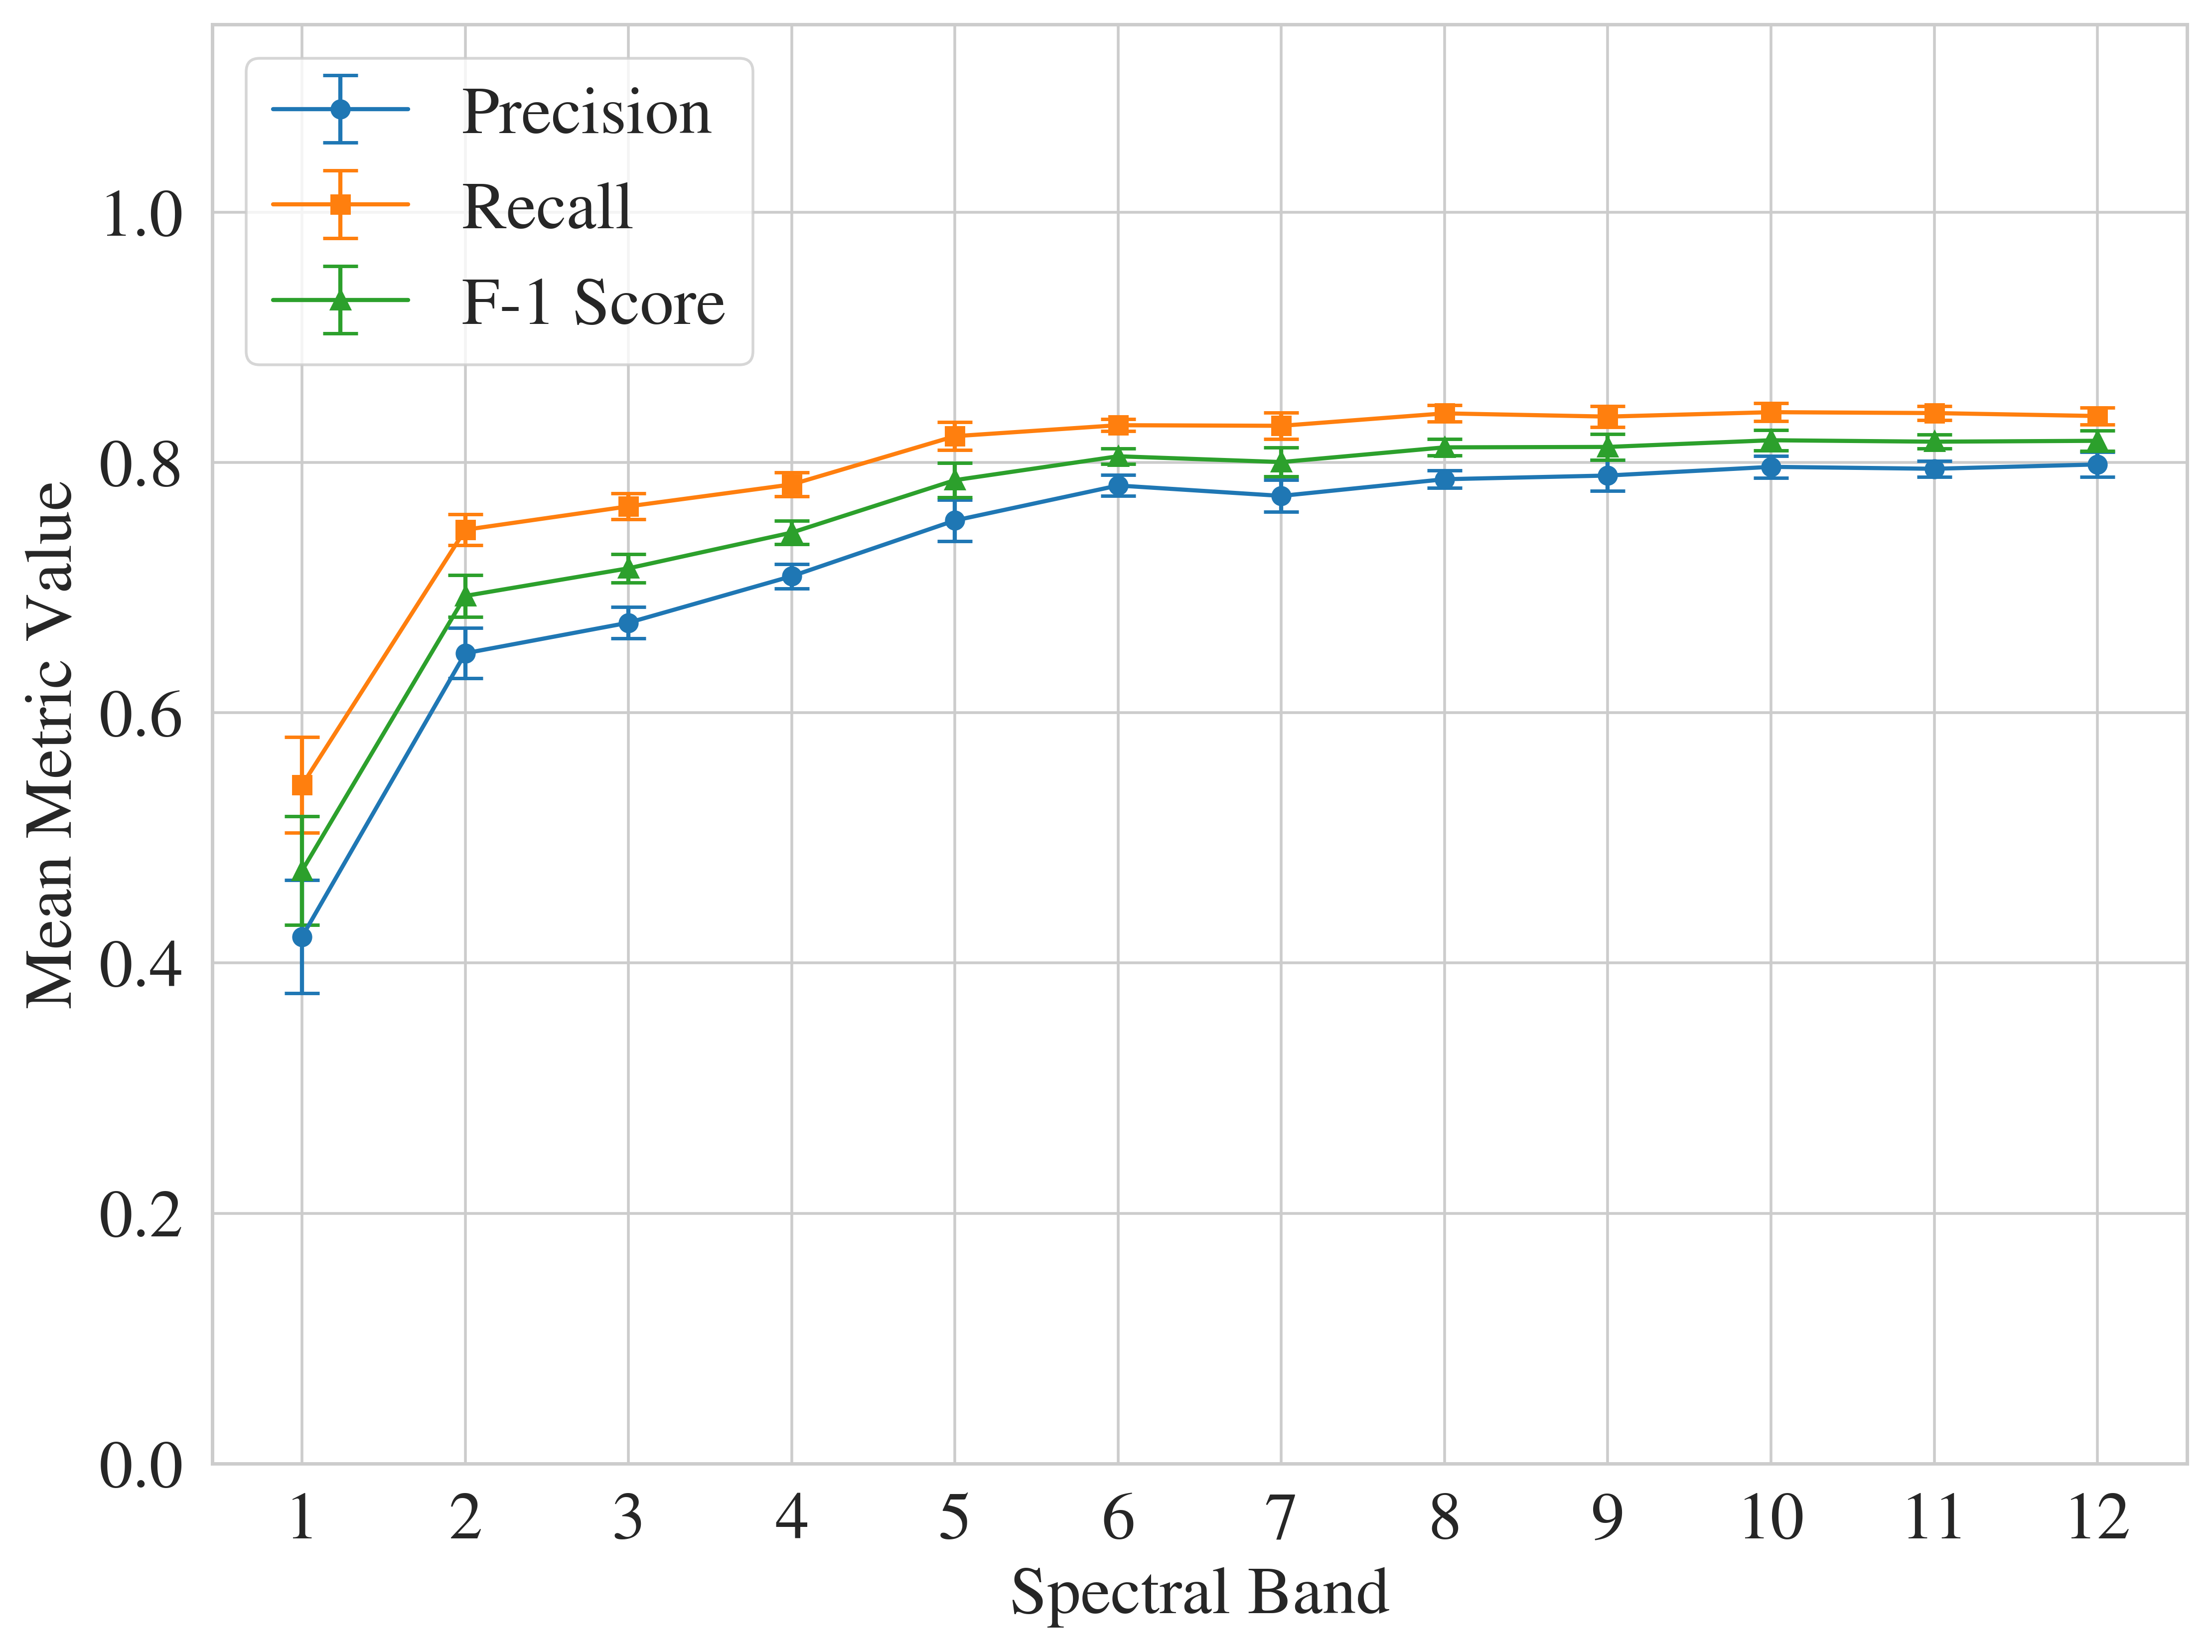

In [4]:
scale_factor = 1.5
plt.figure(figsize=(15 * scale_factor, 5 * scale_factor))

# First subplot: Precision-Recall Curves
ax = plt.subplot(1, 2, 1)

grouped = all_band_best.groupby('Band').agg(
        mean_P=('precision', 'mean'),
        std_P=('precision', 'std'),
        mean_R=('recall', 'mean'),
        std_R=('recall', 'std'),
        mean_F1=('f1_score', 'mean'),
        std_F1=('f1_score', 'std')
    ).reset_index()

grouped = grouped.sort_values(by='Band', key=lambda x: x.map(int), ascending=True)

# Plotting the error bars for each metric
ax.errorbar(grouped['Band'], grouped['mean_P'], yerr=grouped['std_P'], 
                label='Precision', fmt='-o', capsize=5)

ax.errorbar(grouped['Band'], grouped['mean_R'], yerr=grouped['std_R'], 
                label='Recall', fmt='-s', capsize=5)

ax.errorbar(grouped['Band'], grouped['mean_F1'], yerr=grouped['std_F1'], 
                label='F-1 Score', fmt='-^', capsize=5)


ax.set_ylim([0.,1.15])

# if labels is not None:
    # ax.set_xticks(range(len(labels)), labels=labels, fontsize=15)
ax.set_xlabel('Spectral Band')
ax.set_ylabel('Mean Metric Value')
ax.legend(loc='upper left')
ax.grid(True)

grouped.to_pickle('/Data_large/marine/PythonProjects/MMDET/studies/grouped_single_venus.pkl')